# Tarea 3 — Parte 2  
## Starlets 3D y análisis multiescala de fase RM/QSM

Este notebook analiza la representación multiescala de volúmenes de fase de RM empleados en la Tarea 1, utilizando la transformada Starlet 3D:

```text
unwrapped_seguetotalphase.nii   # fase total (`total_phase`)
unwrapped_truelocalphase.nii    # componente local verdadera (`true_local`)
local_vsharp_m4.nii             # componente local estimada con V-SHARP (`vsharp_local`)
mask4.nii                       # máscara ROI (`mask`)
```

El objetivo es estudiar si la representación multiescala permite caracterizar la separación entre:

- componentes suaves (asociadas al campo de fondo, comportamiento armónico),
- componentes locales (variaciones no armónicas).


## Objetivos operacionales

- Implementar y validar una descomposición Starlet 3D.
- Explorar distintos filtros de escalamiento.
- Representar fase total, fase local verdadera y fase local estimada con V-SHARP.
- Analizar energía por escala, reconstrucciones parciales, error multiescala y energía del Laplaciano.

## Datos utilizados

El enunciado usa la notación:

- `bloc`: fase local;
- `btot`: fase total.

En este notebook se usa el siguiente mapeo directo:

| Concepto del enunciado | Archivo usado | Variable |
|---|---|---|
| `btot` | `unwrapped_seguetotalphase.nii` | `total_phase` |
| `bloc` | `unwrapped_truelocalphase.nii` | `local_phase` |
| local estimada | `local_vsharp_m4.nii` | `vsharp_local` |
| máscara | `mask4.nii` | `mask` |

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.ndimage import convolve, laplace
from scipy.stats import pearsonr
import nibabel as nib

# Ajuste de rutas para permitir ejecutar el notebook desde la raíz del repo
# o desde la carpeta notebooks/task3 sin modificar imports ni paths
ROOT = Path.cwd()

if ROOT.name == "task3":
    ROOT = ROOT.parents[1]
elif ROOT.name == "notebooks":
    ROOT = ROOT.parent

SRC = ROOT / "src"
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.append(str(SRC))

DATA_DIR = ROOT / "data" / "raw" / "task1"
RESULTS_DIR = ROOT / "results" / "task3" / "part2_t1"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("RESULTS_DIR:", RESULTS_DIR)

ROOT: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs
DATA_DIR: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/data/raw/task1
RESULTS_DIR: /Users/pabpobar/Proyects/Courses/ProcMultiescImgs/repos/proc-multiesc-imgs/results/task3/part2_t1


In [2]:
# Función auxiliar para guardar figuras con nombres consistentes para el informe
def save_current_fig(filename, dpi=200):
    path = RESULTS_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    #print("Saved:", path)

# 1. Carga de volúmenes NIfTI

Esta sección carga los volúmenes de fase RM/QSM usados en la Tarea 1.

Variables principales:

- `total_phase`: fase total (`unwrapped_seguetotalphase.nii`);
- `true_local`: fase local verdadera (`unwrapped_truelocalphase.nii`);
- `vsharp_local`: fase local estimada con V-SHARP (`local_vsharp_m4.nii`);
- `mask`: máscara ROI (`mask4.nii`);
- `volumes_loaded`: diccionario con los volúmenes cargados.

La fase local verdadera se usa como referencia principal para las métricas.

In [3]:
def load_nifti(path):
    img = nib.load(str(path))
    return img.get_fdata(dtype=np.float64), img.affine, img.header

# Volúmenes utilizados en el análisis: fase total, fase local verdadera
# y estimación local obtenida mediante V-SHARP
VOLUME_FILES = {
    "total_phase": "unwrapped_seguetotalphase.nii",
    "true_local": "unwrapped_truelocalphase.nii",
    "vsharp_local": "local_vsharp_m4.nii",
}

# Se conserva el volumen completo y se restringen los cálculos cuantitativos
# a la región válida definida por la máscara
mask_full, _, _ = load_nifti(DATA_DIR / "mask4.nii")
mask_full = mask_full > 0

volumes_loaded_full = {}

for name, fname in VOLUME_FILES.items():
    vol, _, _ = load_nifti(DATA_DIR / fname)
    volumes_loaded_full[name] = vol

true_local_full = volumes_loaded_full["true_local"]

assert mask_full.shape == true_local_full.shape
assert all(v.shape == true_local_full.shape for v in volumes_loaded_full.values())

mask = mask_full
volumes_loaded = volumes_loaded_full

total_phase = volumes_loaded["total_phase"]
true_local = volumes_loaded["true_local"]
vsharp_local = volumes_loaded["vsharp_local"]

assert mask.shape == true_local.shape
assert all(v.shape == true_local.shape for v in volumes_loaded.values())

print("full shape:", true_local_full.shape, "used shape:", true_local.shape)
print("mask voxels:", int(mask.sum()))

for name, vol in volumes_loaded.items():
    print(f"{name:14s}", vol.shape, "min:", np.nanmin(vol), "max:", np.nanmax(vol))

full shape: (164, 205, 205) used shape: (164, 205, 205)
mask voxels: 1332273
total_phase    (164, 205, 205) min: -83.77690134051623 max: 85.64779938068881
true_local     (164, 205, 205) min: -4.217599391937256 max: 4.492675304412842
vsharp_local   (164, 205, 205) min: -3.4999027252197266 max: 3.422898054122925


# 2. Utilidades de visualización y métricas

Esta sección define funciones reutilizables para:

- mostrar cortes 2D de volúmenes 3D;
- calcular límites de color robustos;
- calcular métricas dentro de la máscara ROI.

Las métricas se calculan dentro de la máscara porque el fondo externo puede contener ceros o valores no informativos.

## Métricas usadas

- **RMSE**: error absoluto respecto de la fase local verdadera (`true_local`).
- **RMSE relativo**: error normalizado por la energía de la referencia.
- **Correlación**: mide la similitud lineal entre volúmenes o componentes multiescala dentro de la máscara.

In [4]:
# Límites robustos para visualización: evita que valores extremos dominen
# el contraste de los cortes mostrados
def robust_limits(x, mask=None, q=(1, 99)):
    vals = np.asarray(x)[mask > 0] if mask is not None else np.asarray(x).ravel()
    vals = vals[np.isfinite(vals)]
    return np.percentile(vals, q)


def get_slice(vol, axis=2, index=None):
    if index is None:
        index = vol.shape[axis] // 2
    if axis == 0:
        return vol[index, :, :]
    if axis == 1:
        return vol[:, index, :]
    if axis == 2:
        return vol[:, :, index]
    raise ValueError("axis must be 0, 1 or 2")


def show_slices(vols, titles, axis=2, index=None, cmap="gray", mask_for_limits=None, figsize=(16, 4)):
    fig, axes = plt.subplots(1, len(vols), figsize=figsize)
    if len(vols) == 1:
        axes = [axes]

    for ax, vol, title in zip(axes, vols, titles):
        sl = get_slice(vol, axis=axis, index=index)

        if mask_for_limits is not None:
            msl = get_slice(mask_for_limits, axis=axis, index=index)
            vmin, vmax = robust_limits(sl, mask=msl)
        else:
            vmin, vmax = robust_limits(sl)

        im = ax.imshow(sl.T, cmap=cmap, origin="lower", vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis("off")
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.tight_layout()
    return fig


# Las métricas se calculan únicamente dentro de la máscara, para evitar
# que voxeles fuera del dominio válido afecten la comparación
def masked_rmse(a, b, mask):
    d = (np.asarray(a) - np.asarray(b))[mask > 0]
    return float(np.sqrt(np.mean(d**2)))


def relative_rmse(a, b, mask):
    ref = np.asarray(a)[mask > 0]
    d = (np.asarray(a) - np.asarray(b))[mask > 0]
    return float(np.sqrt(np.mean(d**2)) / (np.sqrt(np.mean(ref**2)) + 1e-12))


def masked_corr(a, b, mask):
    x = np.asarray(a)[mask > 0].ravel()
    y = np.asarray(b)[mask > 0].ravel()
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 3:
        return np.nan
    return float(pearsonr(x[ok], y[ok])[0])

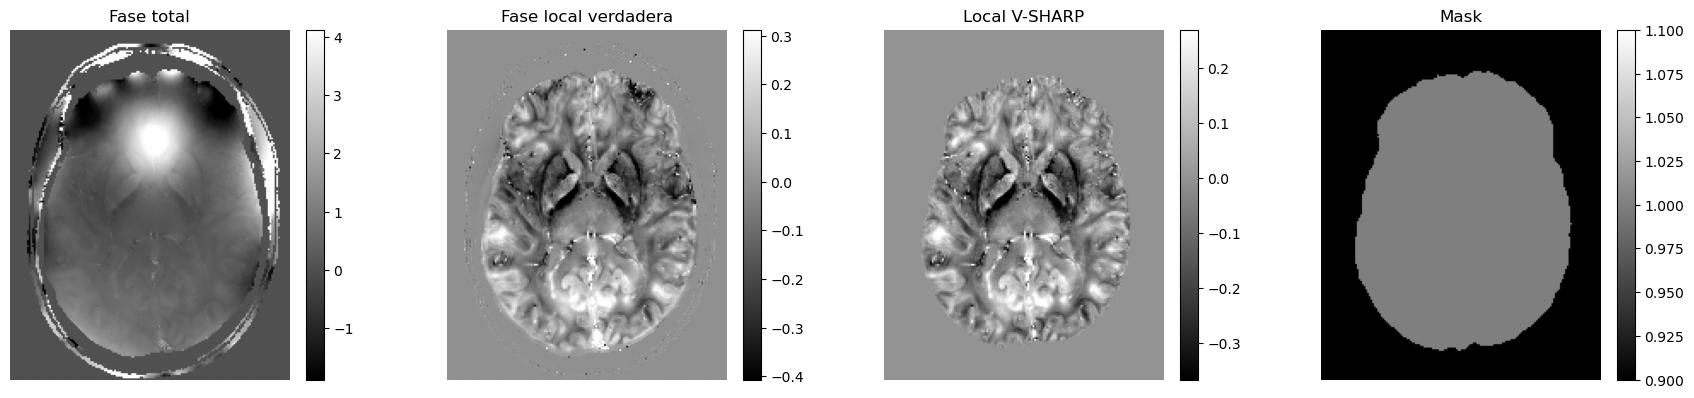

In [5]:
# Visualización inicial de fase total, fase local y máscara
axis = 2
slice_idx = true_local.shape[axis] // 2

fig = show_slices(
    [volumes_loaded["total_phase"], volumes_loaded["true_local"], volumes_loaded["vsharp_local"], mask.astype(float)],
    ["Fase total", "Fase local verdadera", "Local V-SHARP", "Mask"],
    axis=axis,
    index=slice_idx,
    mask_for_limits=mask,
    figsize=(18, 4),
)

# Almacena figura para informe
fig.savefig(RESULTS_DIR / "part32_qsm_2-total_true_vsharp_mask.png", dpi=200, bbox_inches="tight")
plt.show()

## Interpretación de la visualización inicial de fase total, fase local y máscara

La visualización inicial permite comparar los volúmenes principales utilizados en el análisis QSM:

- `total_phase`: fase total, donde se observa una componente suave dominante de gran escala, asociada al campo de fondo;
- `true_local`: fase local verdadera, donde predominan variaciones anatómicas finas y estructuras de alta frecuencia;
- `vsharp_local`: fase local estimada mediante V-SHARP, que reproduce en gran medida la estructura de la fase local;
- `mask`: máscara ROI que define la región válida de análisis.

Se observa claramente que la fase total presenta una variación suave de gran escala superpuesta a la estructura anatómica, mientras que la fase local elimina esta componente, dejando principalmente variaciones locales de alta frecuencia. La estimación V-SHARP logra aproximar este comportamiento, aunque pueden apreciarse pequeñas diferencias en ciertas regiones.

Esta inspección inicial permite verificar que los volúmenes están correctamente alineados y que la máscara cubre adecuadamente la región de interés. Además, proporciona una referencia visual clara de la diferencia entre componentes de fondo (suaves) y componentes locales (de alta frecuencia), lo cual es clave para interpretar posteriormente los resultados multiescala.

En particular, esta comparación anticipa que las diferencias entre `total_phase` y `true_local` estarán asociadas principalmente a componentes de baja frecuencia, mientras que las diferencias entre `vsharp_local` y `true_local` serán más sutiles y localizadas.

# 2.1 Implementación de Starlet 3D

Esta sección importa la implementación `starlet3d.py` del repositorio, si está disponible.  
Si el import falla, el notebook define una implementación local de respaldo.

La Starlet 3D extiende la descomposición multiescala a volúmenes 3D mediante la relación:

$$
w_j = c_{j-1} - c_j
$$

donde:

- $c_j$ es una versión suavizada del volumen en la escala $j$;
- $w_j$ contiene los detalles multiescala;
- $c_J$ corresponde al residual suave.

La reconstrucción cumple:

$$
b = c_J + \sum_j w_j
$$

In [6]:
# Se intenta usar la implementación compartida del repositorio.
# Si no está disponible, se define una implementación local equivalente
# para que el notebook siga siendo ejecutable de forma autónoma
try:
    from course_utils.starlet3d import (
        starlet_transform_3d,
        starlet_reconstruct_3d,
        partial_reconstruction,
        scale_energy,
    )
    print("Usando src/course_utils/starlet3d.py")

except Exception as e:
    print("Usando implementación local:", repr(e))

    def kernel_1d(kind="b3spline"):
        kind = kind.lower()
        if kind in {"b3", "b3spline", "b3-spline", "binomial5", "binom5"}:
            return np.array([1, 4, 6, 4, 1], dtype=float) / 16.0
        if kind in {"binomial3", "binom3"}:
            return np.array([1, 2, 1], dtype=float) / 4.0
        raise ValueError("kernel inválido")

    # Construcción del kernel à trous 3D: el filtro separable se dilata
    # insertando ceros entre coeficientes para aumentar la escala sin submuestreo
    def atrous_kernel_3d(kind="b3spline", level=0):
        h = kernel_1d(kind)
        k = h[:, None, None] * h[None, :, None] * h[None, None, :]

        if level == 0:
            return k

        step = 2 ** level
        size = k.shape[0]
        new_size = size + (size - 1) * (step - 1)
        out = np.zeros((new_size, new_size, new_size), dtype=float)

        for i in range(size):
            for j in range(size):
                for z in range(size):
                    out[i * step, j * step, z * step] = k[i, j, z]

        return out

    # Descomposición Starlet 3D: en cada nivel se calcula una aproximación
    # suavizada c_j y el detalle w_j = c_{j-1} - c_j
    def starlet_transform_3d(volume, n_scales=5, kernel="b3spline", mode="mirror"):
        c = np.asarray(volume, dtype=float).copy()
        details = []
        approximations = [c.copy()]

        for level in range(n_scales):
            cn = convolve(c, atrous_kernel_3d(kernel, level), mode=mode)
            details.append(c - cn)
            c = cn
            approximations.append(c.copy())

        return details, c, approximations

    def starlet_reconstruct_3d(details, cJ):
        rec = np.asarray(cJ, dtype=float).copy()
        for w in details:
            rec += w
        return rec

    def partial_reconstruction(details, cJ=None, scales=None, include_residual=False):
        idxs = range(len(details)) if scales is None else [s - 1 for s in scales]
        rec = np.zeros_like(details[0], dtype=float)

        for i in idxs:
            rec += details[i]

        if include_residual:
            if cJ is None:
                raise ValueError("cJ requerido si include_residual=True")
            rec += cJ

        return rec

    def scale_energy(details, mask=None, relative=True):
        e = []
        for w in details:
            vals = w[mask > 0] if mask is not None else w.ravel()
            e.append(np.sum(vals**2))
        e = np.asarray(e, dtype=float)

        if relative and e.sum() > 0:
            e = e / e.sum()

        return e

Usando src/course_utils/starlet3d.py


# 2.1.1 Validación de reconstrucción y descomposición principal

Esta sección cumple la parte de implementación de Starlet 3D.

Primero se valida que la reconstrucción sea exacta o cercana a error numérico:

$$
b ≈ c_J + \sum_j w_j
$$

Luego se calcula la descomposición para los volúmenes seleccionados.

## Qué significa el error de reconstrucción

Un error máximo cercano a cero indica que la descomposición y reconstrucción Starlet están correctamente implementadas.

In [7]:
N_SCALES = 5
# Se utilizan cinco niveles para cumplir el requisito de la tarea y analizar
# la distribución de información desde escalas finas hasta el residual
KERNELS = ["b3spline", "binomial3"]

# Validación numérica de la reconstrucción: la suma de detalles y residual
# debe recuperar el volumen original, salvo error numérico
for kernel in KERNELS:
    d, cJ, _ = starlet_transform_3d(volumes_loaded["true_local"] * mask, n_scales=N_SCALES, kernel=kernel)
    rec = starlet_reconstruct_3d(d, cJ)
    print(kernel, "max reconstruction error:", np.max(np.abs(volumes_loaded["true_local"] * mask - rec)))

# Se aplica la máscara antes de descomponer para restringir el análisis
# al dominio anatómico válido
volumes = {name: vol * mask for name, vol in volumes_loaded.items()}

decompositions = {}

for name, vol in volumes.items():
    for kernel in KERNELS:
        d, cJ, a = starlet_transform_3d(vol, n_scales=N_SCALES, kernel=kernel)
        decompositions[(name, kernel)] = {
            "details": d,
            "cJ": cJ,
            "approximations": a,
            "reconstruction": starlet_reconstruct_3d(d, cJ),
        }

print("decompositions:", len(decompositions))

b3spline max reconstruction error: 4.440892098500626e-16
binomial3 max reconstruction error: 8.881784197001252e-16
decompositions: 6


# 2.2.1 Visualización de capas multiescala

Esta sección muestra las capas Starlet para los volúmenes de fase considerados.

Para cada volumen se visualizan:

- $|w_1|, |w_2|, \ldots, |w_5|$: detalles por escala;
- $c_J$: residual suave.

## Interpretación

Las capas multiescala permiten observar claramente cómo se distribuyen las distintas componentes de la fase en función de la escala.

En la fase total, las escalas gruesas ($w_5$ y especialmente $c_J$) dominan la representación, mostrando una estructura suave de gran escala asociada al campo de fondo. Las escalas intermedias ($w_3$, $w_4$) contienen una transición entre esta componente suave y las variaciones locales, mientras que las escalas finas ($w_1$, $w_2$) capturan principalmente bordes y detalles de alta frecuencia.

En contraste, la fase local verdadera presenta una concentración mucho mayor de energía en las escalas finas, donde se observan claramente las estructuras anatómicas. Las componentes gruesas y el residual son significativamente más débiles, lo que indica la ausencia del campo de fondo.

Para la estimación V-SHARP, se observa un comportamiento similar al de la fase local en las escalas finas, lo que indica una buena recuperación de las variaciones locales. Sin embargo, las componentes de baja frecuencia ($w_5$ y $c_J$) son más pronunciadas que en la fase local verdadera, lo que sugiere que el campo de fondo no es completamente eliminado.

En conjunto, esta visualización muestra que la descomposición multiescala permite distinguir de forma clara entre componentes suaves de baja frecuencia, asociadas al fondo, y componentes locales de alta frecuencia, lo que constituye la base del análisis posterior.

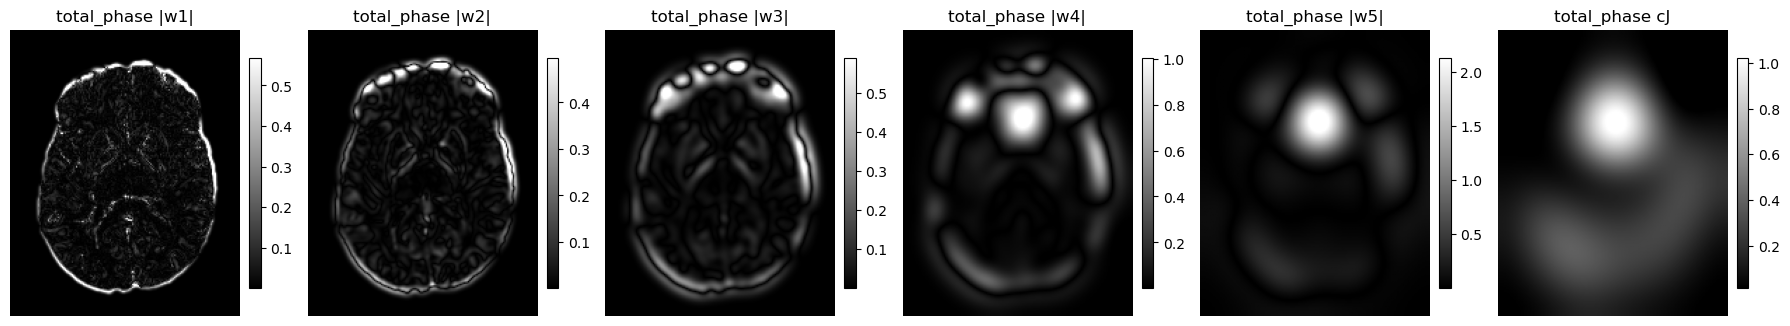

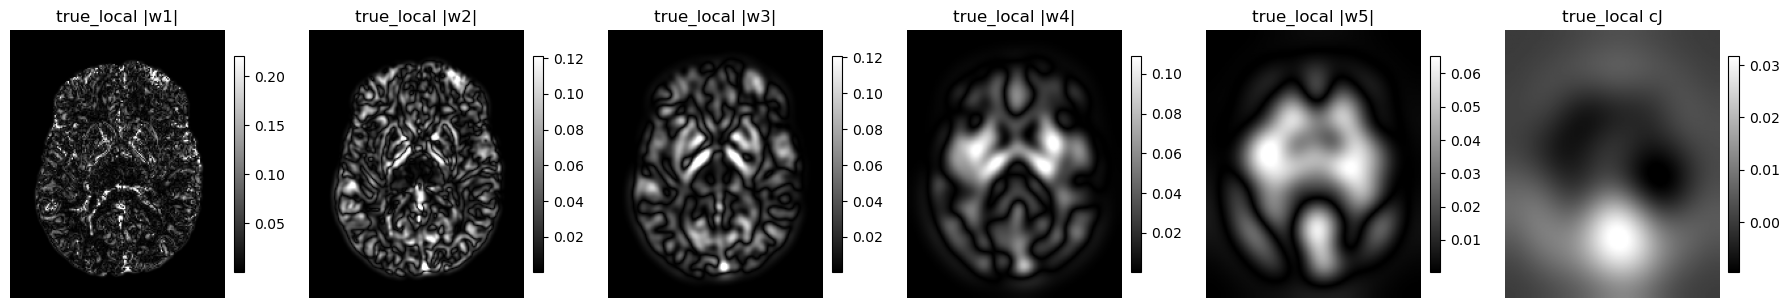

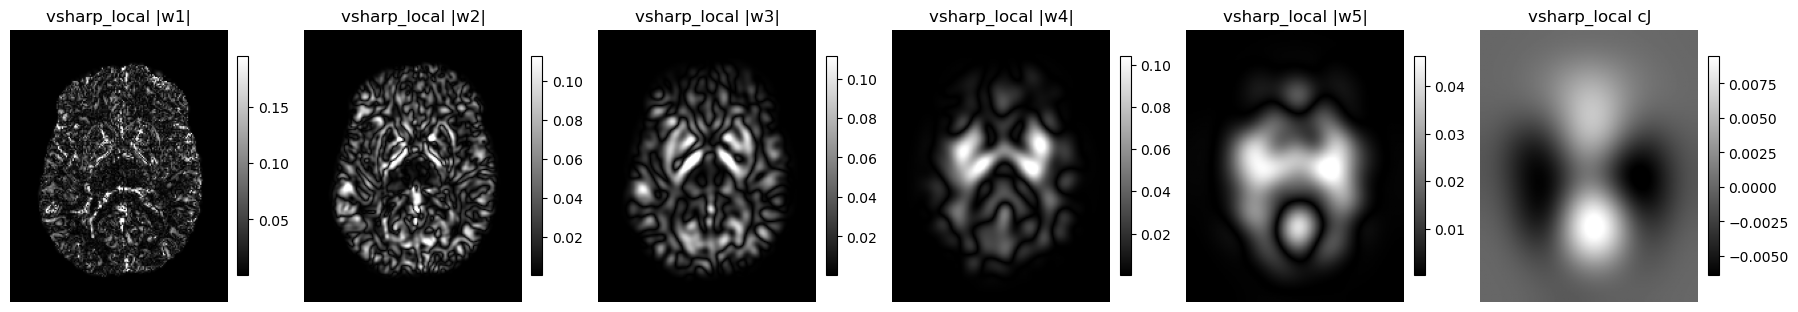

In [8]:
def show_starlet_layers(details, cJ, title_prefix, axis=2, index=None):
    # Se visualiza la magnitud de los detalles para comparar el contenido
    # relativo capturado por cada escala
    imgs = [np.abs(w) for w in details] + [cJ]
    titles = [f"{title_prefix} |w{j}|" for j in range(1, len(details) + 1)] + [f"{title_prefix} cJ"]

    fig = show_slices(
        imgs,
        titles,
        axis=axis,
        index=index,
        mask_for_limits=mask,
        figsize=(18, 4),
    )

    safe_name = title_prefix.replace(" ", "_")
    fig.savefig(RESULTS_DIR / f"part32_qsm_21-{safe_name}.png", dpi=200, bbox_inches="tight")
    plt.show()


for name in ["total_phase", "true_local", "vsharp_local"]:
    dec = decompositions[(name, "b3spline")]
    show_starlet_layers(dec["details"], dec["cJ"], name, axis=axis, index=slice_idx)

# 2.2.2 Energía relativa por escala

Esta sección calcula cuánta energía concentra cada volumen en cada escala Starlet.

La energía relativa por escala permite analizar cómo se distribuyen las distintas componentes de la fase en función de la escala.

En particular, permite responder preguntas como:

- ¿la fase total concentra mayor energía en escalas gruesas debido a la presencia de campo de fondo?
- ¿la fase local verdadera presenta mayor energía en escalas finas asociadas a variaciones anatómicas?
- ¿la estimación V-SHARP reproduce adecuadamente la distribución de energía de la fase local?

Una mayor energía en escalas finas se asocia a variaciones locales o componentes no armónicas, mientras que una mayor energía en escalas gruesas se relaciona con estructuras suaves de baja frecuencia.

,volume,kernel,scale,relative_energy
0,total_phase,b3spline,1,0.113277
1,total_phase,b3spline,2,0.069203
2,total_phase,b3spline,3,0.137571
3,total_phase,b3spline,4,0.290200
4,total_phase,b3spline,5,0.389750
5,total_phase,binomial3,1,0.094006
6,total_phase,binomial3,2,0.059466
7,total_phase,binomial3,3,0.114282
8,total_phase,binomial3,4,0.254191
9,total_phase,binomial3,5,0.478055


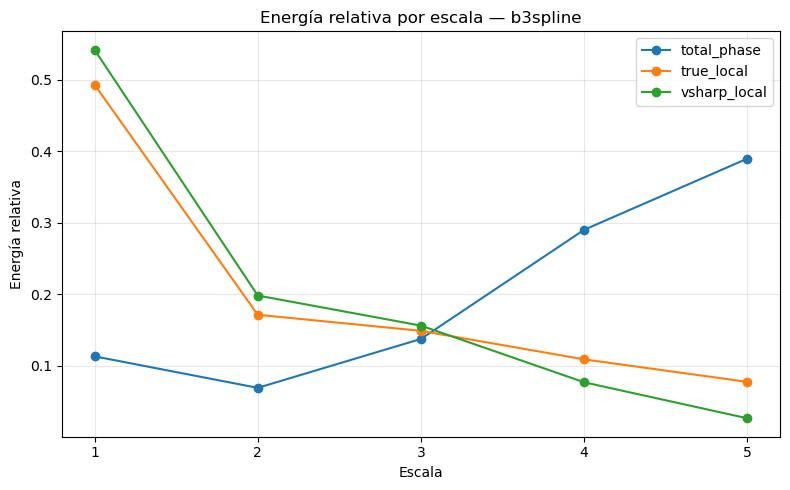

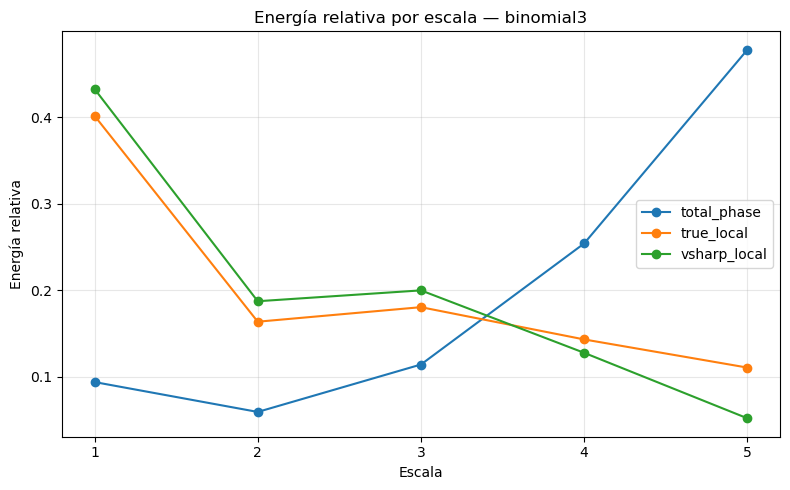

In [9]:
# La energía relativa por escala permite identificar en qué niveles se
# concentra la información de cada volumen
energy_rows = []

for name in volumes:
    for kernel in KERNELS:
        energies = scale_energy(decompositions[(name, kernel)]["details"], mask=mask, relative=True)

        for j, e in enumerate(energies, start=1):
            energy_rows.append({
                "volume": name,
                "kernel": kernel,
                "scale": j,
                "relative_energy": e,
            })

df_energy = pd.DataFrame(energy_rows)
display(df_energy)

df_energy.to_csv(RESULTS_DIR / "part2_starlet3d_scale_energy.csv", index=False)

# Se genera un gráfico por kernel para comparar cómo cambia la distribución
# de energía entre fase total, fase local y V-SHARP
for kernel in KERNELS:
    plt.figure(figsize=(8, 5))
    for name in volumes:
        s = df_energy[(df_energy["kernel"] == kernel) & (df_energy["volume"] == name)]
        plt.plot(s["scale"], s["relative_energy"], marker="o", label=name)

    plt.title(f"Energía relativa por escala — {kernel}")
    plt.xlabel("Escala")
    plt.ylabel("Energía relativa")
    plt.xticks(range(1, N_SCALES + 1))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    # Almacena imagen para informe
    save_current_fig(f"part32_22_energy_{kernel}.png")
    plt.show()

## Interpretación de la tabla de energía

La tabla `df_energy` muestra la distribución de energía relativa por escala para cada volumen.

Este análisis permite comparar directamente el comportamiento multiescala entre la fase total, la fase local verdadera y la estimación V-SHARP.

En particular, se observa que:

- la fase total concentra una proporción importante de energía en escalas gruesas, lo que confirma la presencia dominante de componentes de fondo;
- la fase local verdadera presenta mayor peso relativo en escalas finas, consistente con variaciones anatómicas de alta frecuencia;
- la estimación V-SHARP reproduce en gran medida esta distribución, aunque mantiene una ligera contribución en escalas gruesas, lo que sugiere una eliminación incompleta del fondo.

El gráfico asociado permite visualizar estas diferencias y evaluar si la separación entre componentes suaves y locales es consistente entre los distintos volúmenes.

# 2.2.3 Reconstrucciones parciales por grupos de escalas

Esta sección reconstruye componentes parciales a partir de la descomposición Starlet:

- $w_1 + w_2$: componentes finas;
- $w_3 + w_4$: componentes medias;
- $w_5$: detalle grueso;
- $c_J$: residual suave.

## Objetivo

Separar visualmente qué estructuras aparecen en cada rango de escala y cómo contribuyen a la formación del volumen.

## Interpretación

En la fase total, se observa que las componentes gruesas ($w_5$ y $c_J$) dominan la señal, mostrando una estructura suave de gran escala. Esto es consistente con la presencia de campo de fondo, que introduce variaciones de baja frecuencia.

En contraste, la fase local verdadera presenta una mayor concentración de información en las escalas finas ($w_1 + w_2$), donde se observan claramente estructuras anatómicas. Las componentes gruesas son significativamente más débiles, lo que indica la ausencia del campo de fondo.

Para la estimación V-SHARP, se observa un comportamiento intermedio. Las componentes finas son similares a las de la fase local verdadera, lo que indica una buena recuperación de la estructura local. Sin embargo, las componentes de baja frecuencia ($w_5$ y $c_J$) son más pronunciadas que en la fase local, lo que sugiere que el campo de fondo no es completamente eliminado.

En conjunto, estas observaciones muestran que la descomposición multiescala permite distinguir claramente entre componentes suaves asociadas al fondo y componentes locales no armónicas, proporcionando evidencia visual de la separación entre ambas.

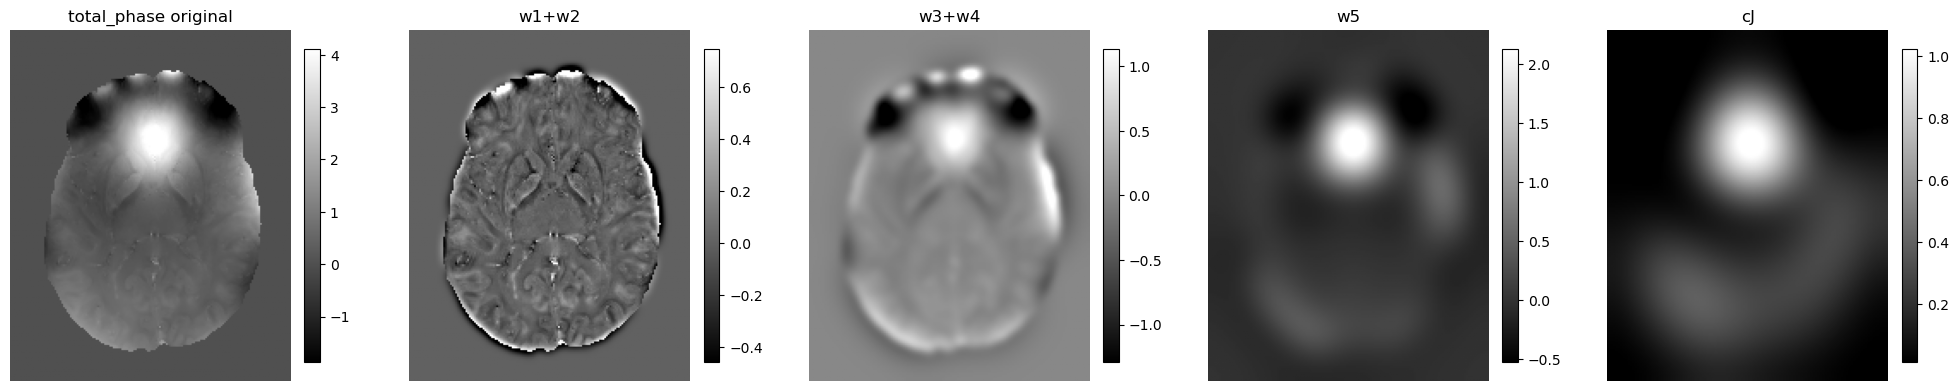

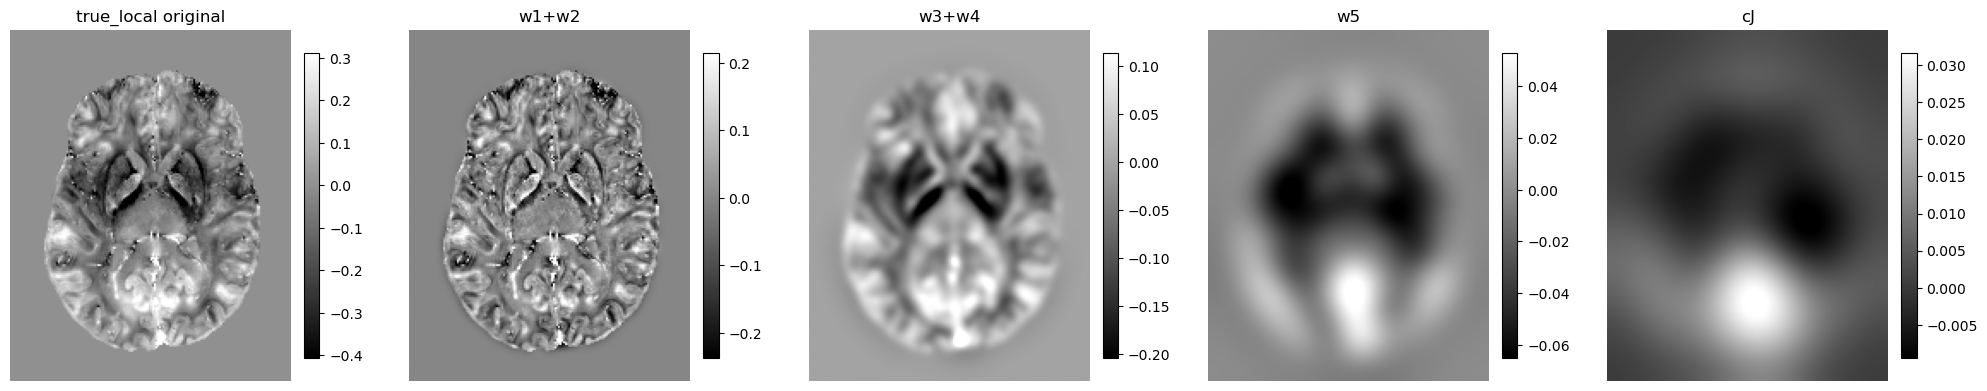

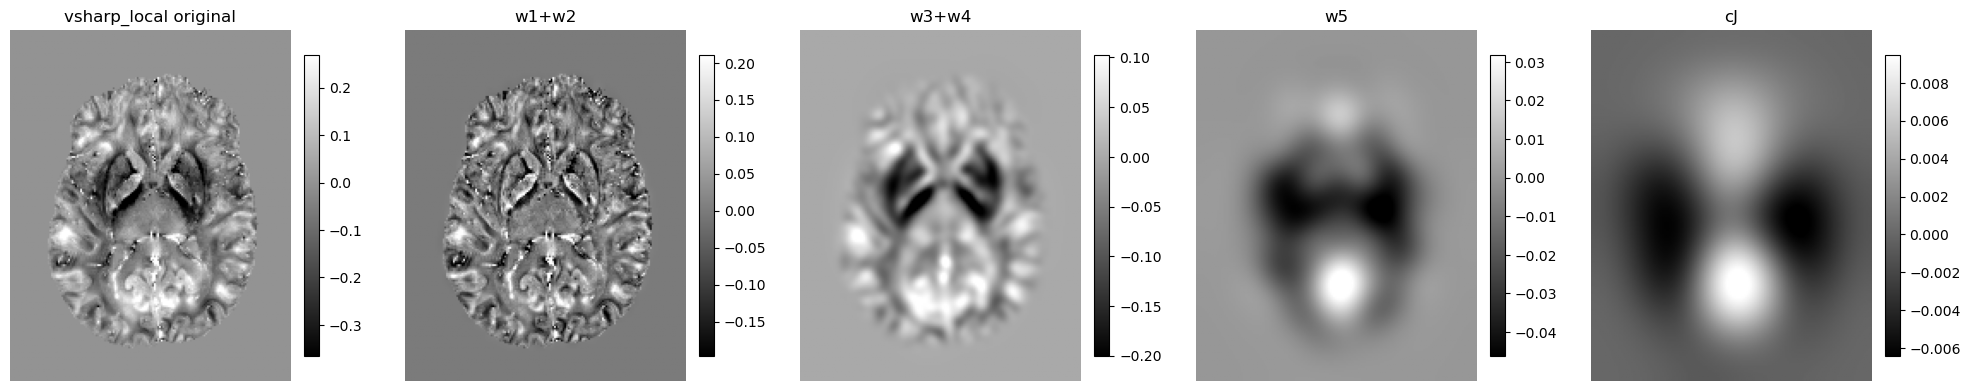

In [10]:
def summarize_partial(name, kernel="b3spline"):
    dec = decompositions[(name, kernel)]
    d = dec["details"]
    cJ = dec["cJ"]

    # Se agrupan escalas finas, intermedias y gruesas para interpretar
    # cualitativamente qué estructuras aporta cada rango multiescala
    fine = partial_reconstruction(d, scales=[1, 2])
    mid = partial_reconstruction(d, scales=[3, 4])
    coarse = partial_reconstruction(d, scales=[5])

    fig = show_slices(
        [volumes[name], fine, mid, coarse, cJ],
        [f"{name} original", "w1+w2", "w3+w4", "w5", "cJ"],
        axis=axis,
        index=slice_idx,
        mask_for_limits=mask,
        figsize=(20, 4),
    )

    safe_name = name.replace(" ", "_")
    fig.savefig(RESULTS_DIR / f"part32_qsm_23-Reconst_parciales_{safe_name}.png", dpi=200, bbox_inches="tight")
    plt.show()


for name in ["total_phase", "true_local", "vsharp_local"]:
    summarize_partial(name)

# 2.2.4 Error multiescala respecto de la fase local verdadera

Esta sección compara la fase total y la estimación V-SHARP respecto a la fase local verdadera (`true_local`) escala por escala.

Para cada componente $w_j$ y para el residual $c_J$, se calculan:

- RMSE respecto de la fase local verdadera;
- RMSE relativo;
- correlación.

## Interpretación

El análisis muestra comportamientos claramente diferenciados entre los volúmenes.

Para la fase total, el error aumenta significativamente hacia las escalas gruesas ($w_4$, $w_5$ y $c_J$), lo que indica que las principales diferencias respecto a la fase local se concentran en componentes de baja frecuencia. Este resultado es consistente con la presencia de campo de fondo, el cual no está presente en la fase local verdadera.

En contraste, la estimación V-SHARP presenta errores bajos en todas las escalas, lo que indica una buena aproximación a la fase local. Sin embargo, se observa que el error es ligeramente mayor en las escalas finas, lo que sugiere pequeñas diferencias en la recuperación de variaciones locales.

En conjunto, estos resultados confirman que la representación multiescala permite distinguir entre componentes de fondo y componentes locales, mostrando que las diferencias asociadas al campo de fondo se manifiestan principalmente en las escalas más gruesas.

,volume,kernel,component,RMSE_to_true_local,relative_RMSE_to_true_local,correlation_to_true_local
0,total_phase,b3spline,w1,0.269793,3.997522,0.201376
1,total_phase,b3spline,w2,0.210865,5.299694,0.197236
2,total_phase,b3spline,w3,0.300946,8.114718,0.122869
3,total_phase,b3spline,w4,0.440544,13.884087,0.032026
4,total_phase,b3spline,w5,0.509933,19.055175,0.041626
5,total_phase,b3spline,cJ,0.311214,19.715282,0.373750
6,total_phase,binomial3,w1,0.222234,3.853496,0.199011
7,total_phase,binomial3,w2,0.175989,4.779715,0.211924
8,total_phase,binomial3,w3,0.246315,6.370672,0.162871
9,total_phase,binomial3,w4,0.371224,10.778521,0.077636


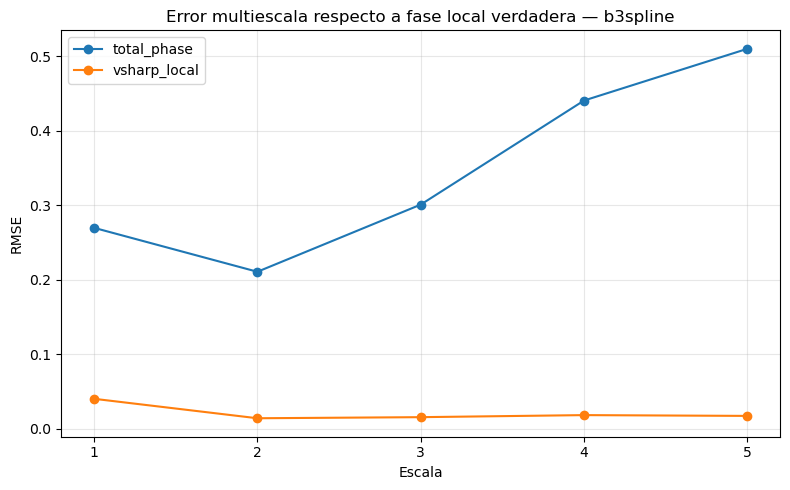

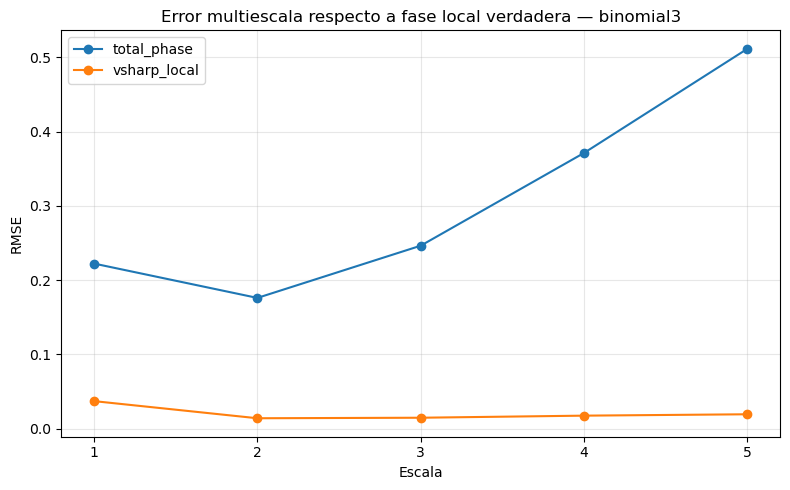

In [11]:
error_rows = []

# La fase local verdadera se usa como referencia para analizar errores multiescala
REFERENCE = "true_local"

# Se compara cada componente multiescala contra la componente equivalente
# de la fase local verdadera, no contra el volumen completo
for name in volumes:
    if name == REFERENCE:
        continue

    for kernel in KERNELS:
        ref = decompositions[(REFERENCE, kernel)]
        est = decompositions[(name, kernel)]

        for j, (wr, we) in enumerate(zip(ref["details"], est["details"]), start=1):
            error_rows.append({
                "volume": name,
                "kernel": kernel,
                "component": f"w{j}",
                "RMSE_to_true_local": masked_rmse(wr, we, mask),
                "relative_RMSE_to_true_local": relative_rmse(wr, we, mask),
                "correlation_to_true_local": masked_corr(wr, we, mask),
            })

        error_rows.append({
            "volume": name,
            "kernel": kernel,
            "component": "cJ",
            "RMSE_to_true_local": masked_rmse(ref["cJ"], est["cJ"], mask),
            "relative_RMSE_to_true_local": relative_rmse(ref["cJ"], est["cJ"], mask),
            "correlation_to_true_local": masked_corr(ref["cJ"], est["cJ"], mask),
        })

df_multiscale_error = pd.DataFrame(error_rows)
display(df_multiscale_error)

df_multiscale_error.to_csv(RESULTS_DIR / "part2_qsm_multiscale_error_to_true_local.csv", index=False)

for kernel in KERNELS:
    subset = df_multiscale_error[
        (df_multiscale_error["kernel"] == kernel)
        & (df_multiscale_error["component"].str.startswith("w"))
    ].copy()

    # Para graficar el error por escala se consideran solo las capas w_j;
    # el residual cJ se analiza por separado en la tabla
    subset["scale"] = subset["component"].str.replace("w", "", regex=False).astype(int)

    plt.figure(figsize=(8, 5))
    for name in subset["volume"].unique():
        s = subset[subset["volume"] == name]
        plt.plot(s["scale"], s["RMSE_to_true_local"], marker="o", label=name)

    plt.title(f"Error multiescala respecto a fase local verdadera — {kernel}")
    plt.xlabel("Escala")
    plt.ylabel("RMSE")
    plt.xticks(range(1, N_SCALES + 1))
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()

    save_current_fig(f"part32_qsm_24-Error_multiescala_true_local_{kernel}.png")
    plt.show()

# 2.2.5 Métricas globales y energía del Laplaciano

Esta sección resume dos análisis complementarios sobre los volúmenes de fase.

## Métricas globales

Se comparan los volúmenes `total_phase` y `vsharp_local` respecto a la fase local verdadera (`true_local`) utilizando:

- RMSE;
- RMSE relativo;
- correlación.

Estos indicadores permiten evaluar qué tan cerca se encuentra cada volumen de la componente local de referencia.

En particular, se observa que la fase total presenta un error significativamente mayor, lo que es consistente con la presencia de componentes de fondo. Por otro lado, la estimación V-SHARP muestra errores considerablemente menores, indicando una buena aproximación a la fase local verdadera.

## Energía del Laplaciano

El operador Laplaciano se utiliza como un indicador de no suavidad o desviación del comportamiento armónico. Para una función armónica ideal se cumple:

$$
\Delta b \approx 0
$$

Por lo tanto:

- una baja energía del Laplaciano indica estructuras suaves, asociadas a componentes de baja frecuencia
- una alta energía del Laplaciano indica variaciones locales, bordes o componentes no armónicas.

A partir de las visualizaciones, se observa que:

- la fase total presenta una combinación de componentes locales y una estructura suave dominante, donde el residual ($c_J$) concentra principalmente la componente de baja frecuencia;
- la fase local verdadera muestra una alta respuesta del Laplaciano en las componentes finas, consistente con su carácter no armónico;
- la estimación V-SHARP reproduce en gran medida el comportamiento de la fase local, aunque mantiene una pequeña componente de baja frecuencia, evidenciada en el residual.

## Limitación

Este análisis no permite distinguir de forma exacta entre componentes armónicas y no armónicas. El uso del Laplaciano constituye una aproximación basada en la regularidad espacial, útil para interpretar el comportamiento de las distintas escalas, pero no reemplaza una caracterización física exacta del campo.

In [12]:
# Comparación global: mide qué tan cerca están la fase total y V-SHARP
# de la fase local verdadera dentro de la máscara
global_rows = []
REFERENCE = "true_local"

for name, vol in volumes.items():
    if name == REFERENCE:
        continue

    global_rows.append({
        "volume": name,
        "RMSE_to_true_local": masked_rmse(volumes[REFERENCE], vol, mask),
        "relative_RMSE_to_true_local": relative_rmse(volumes[REFERENCE], vol, mask),
        "correlation_to_true_local": masked_corr(volumes[REFERENCE], vol, mask),
    })

df_global = pd.DataFrame(global_rows).sort_values("RMSE_to_true_local")
display(df_global)

df_global.to_csv(RESULTS_DIR / "part2_qsm_global_metrics_to_true_local.csv", index=False)

# La energía del Laplaciano se usa como indicador simple de contenido
# de alta frecuencia en el volumen original, el pasaaltos y el residual
lap_rows = []

for name, vol in volumes.items():
    for kernel in KERNELS:
        dec = decompositions[(name, kernel)]
        d = dec["details"]
        cJ = dec["cJ"]

        # La suma de todos los detalles actúa como componente pasaaltos multiescala
        hp = partial_reconstruction(d, scales=list(range(1, N_SCALES + 1)))

        for cname, comp in {"original": vol, "sum_details": hp, "residual_cJ": cJ}.items():
            lp = laplace(comp)
            lap_rows.append({
                "volume": name,
                "kernel": kernel,
                "component": cname,
                "mean_laplacian_energy": float(np.mean(lp[mask > 0] ** 2)),
            })

df_lap = pd.DataFrame(lap_rows)
display(df_lap)

df_lap.to_csv(RESULTS_DIR / "part2_qsm_laplacian_energy.csv", index=False)

,volume,RMSE_to_true_local,relative_RMSE_to_true_local,correlation_to_true_local
1,vsharp_local,0.077027,0.545962,0.838021
0,total_phase,1.595360,11.307760,0.094495


,volume,kernel,component,mean_laplacian_energy
0,total_phase,b3spline,original,2.020640e+00
1,total_phase,b3spline,sum_details,2.020022e+00
2,total_phase,b3spline,residual_cJ,2.766170e-06
3,total_phase,binomial3,original,2.020640e+00
4,total_phase,binomial3,sum_details,2.018953e+00
5,total_phase,binomial3,residual_cJ,1.638703e-05
6,true_local,b3spline,original,1.208612e-01
7,true_local,b3spline,sum_details,1.208607e-01
8,true_local,b3spline,residual_cJ,6.428104e-09
9,true_local,binomial3,original,1.208612e-01


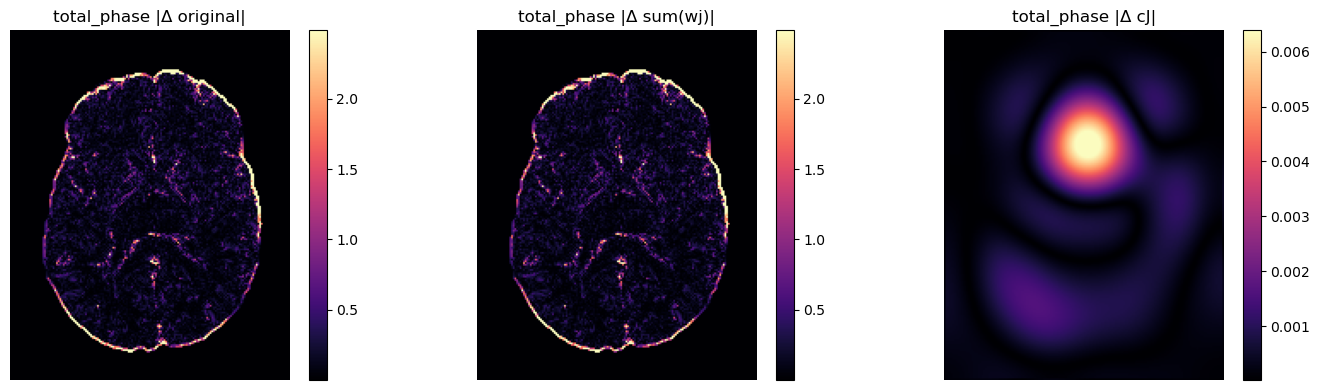

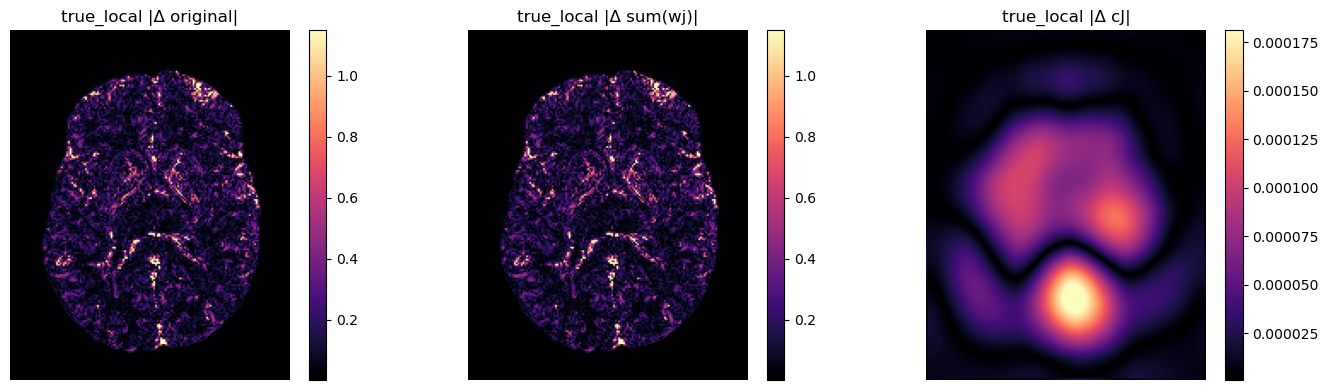

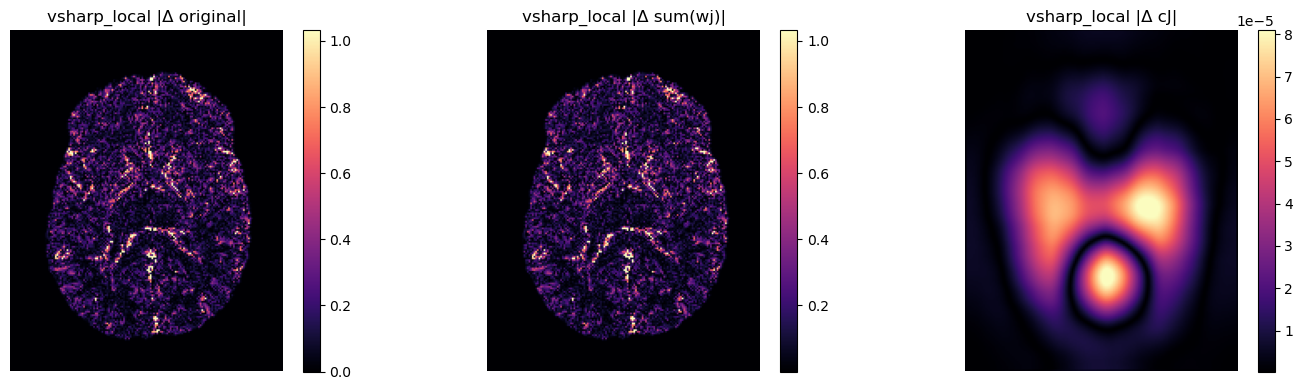

In [13]:
# Visualización del Laplaciano
for name in ["total_phase", "true_local", "vsharp_local"]:
    dec = decompositions[(name, "b3spline")]
    
    # Se compara el contenido de alta frecuencia del volumen original,
    # de la suma de detalles y del residual suave
    hp = partial_reconstruction(dec["details"], scales=list(range(1, N_SCALES + 1)))

    fig = show_slices(
        [
            np.abs(laplace(volumes[name])),
            np.abs(laplace(hp)),
            np.abs(laplace(dec["cJ"])),
        ],
        [
            f"{name} |Δ original|",
            f"{name} |Δ sum(wj)|",
            f"{name} |Δ cJ|",
        ],
        axis=axis,
        index=slice_idx,
        cmap="magma",
        mask_for_limits=mask,
        figsize=(15, 4),
    )

    # Almacena imagen para informe
    fig.savefig(
        RESULTS_DIR / f"part32_qsm_25-laplacian_energy_{name}.png",
        dpi=200,
        bbox_inches="tight",
    )
    plt.show()

# 2.2.6 Discusión preliminar

Esta sección resume las principales interpretaciones derivadas del análisis multiescala.

## Ideas principales

1. **Representación multiescala:**  
   La transformada Starlet 3D permite representar la fase total, la fase local verdadera y la estimación V-SHARP como la suma de componentes multiescala y un residual suave, facilitando el análisis por rangos de frecuencia.

2. **Componentes de fondo (suaves):**  
   Se observa que la fase total concentra una proporción importante de energía en escalas gruesas y en el residual, lo que es consistente con la presencia de campo de fondo.

3. **Componentes locales no armónicas:**  
   La fase local verdadera presenta mayor energía en escalas finas y una respuesta elevada del Laplaciano, lo que refleja su carácter no armónico y su asociación con variaciones anatómicas.

4. **Comportamiento de V-SHARP:**  
   La estimación V-SHARP reproduce adecuadamente las componentes finas de la fase local, pero mantiene una pequeña componente de baja frecuencia, lo que sugiere una eliminación incompleta del campo de fondo.

5. **Rol del Laplaciano:**  
   El Laplaciano permite identificar regiones con variaciones locales intensas, aunque no constituye una separación exacta entre componentes armónicas y no armónicas, sino una aproximación basada en regularidad espacial.

6. **Consistencia con análisis previo:**  
   Estos resultados son consistentes con la Parte 3 de la Tarea 1, donde las representaciones multiescala permitían separar componentes suaves y detalles de alta frecuencia. En este caso, el uso de Starlets 3D permite extender este análisis a volúmenes completos.


# Cierre de Parte 2

Este notebook cubre:

- **2.1:** implementación, validación y reconstrucción de la transformada Starlet 3D;
- **2.2:** análisis multiescala de volúmenes de fase utilizando capas, energía por escala, reconstrucciones parciales, error respecto de la fase local verdadera y energía del Laplaciano.

## Alcance del análisis

La separación entre componentes armónicas y no armónicas se aborda como una interpretación basada en la descomposición multiescala:

- el residual $c_J$ concentra principalmente contenido suave de baja frecuencia, asociado al campo de fondo;
- los detalles $w_j$ capturan variaciones locales organizadas por escala;
- la energía del Laplaciano aporta evidencia sobre la presencia de estructuras no suaves o no armónicas.

Los resultados muestran que la fase total concentra mayor energía en escalas gruesas, mientras que la fase local verdadera presenta mayor contenido en escalas finas, lo que es consistente con la interpretación física del problema.

En conjunto, estos resultados muestran que la transformada Starlet 3D permite no solo analizar la señal en distintos niveles de escala, sino también interpretar de forma efectiva la separación entre componentes de fondo y componentes locales en imágenes de fase de RM.

## Limitación

La transformada Starlet 3D no impone explícitamente condiciones armónicas ni resuelve un problema físico de QSM. Por tanto, los resultados deben interpretarse como un análisis multiescala de la fase, y no como una separación armónica exacta del campo.

## Archivos generados

```text
results/task3/part2_t1/part2_starlet3d_scale_energy.csv
results/task3/part2_t1/part2_qsm_multiscale_error_to_true_local.csv
results/task3/part2_t1/part2_qsm_global_metrics_to_true_local.csv
results/task3/part2_t1/part2_laplacian_energy.csv